# Supervised Algorithms Homework

In this homework assignment, you will apply three fundamental machine learning algorithms to famous datasets:

1. **Linear Regression**: Boston Housing Price Prediction
2. **Logistic Regression**: Breast Cancer Classification
3. **Decision Tree**: Titanic Survival Prediction

### Instructions

- Implement **at least** one algorithm
- Complete each section carefully
- Add your code where indicated by `# YOUR CODE HERE`
- Provide comments explaining your approach

In [4]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Specific Algorithms
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Metrics and Datasets
from sklearn.datasets import fetch_openml
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, mean_absolute_error

# Set random seed for reproducibility
np.random.seed(42)

# 1: Linear Regression - Boston Housing Price Prediction

### Task
- Load the Boston Housing dataset
- Preprocess the data
- Split into training and testing sets
- Train a Linear Regression model
- Evaluate model performance

In [25]:
# Load Boston Housing dataset
boston = fetch_openml(name="boston", version=1, as_frame=True)

# Extract features and target
X, y = boston.data, boston.target

In [26]:
# TODO: Split the data into training and testing sets
# Uso train_test_split usando la proporzione generica 80/20, e il random state per la riproducibilità
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)

In [27]:
X_train.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
477,15.02340,0.0,18.10,0,0.6140,5.304,97.3,2.1007,24,666.0,20.2,349.48,24.91
15,0.62739,0.0,8.14,0,0.5380,5.834,56.5,4.4986,4,307.0,21.0,395.62,8.47
332,0.03466,35.0,6.06,0,0.4379,6.031,23.3,6.6407,1,304.0,16.9,362.25,7.83
423,7.05042,0.0,18.10,0,0.6140,6.103,85.1,2.0218,24,666.0,20.2,2.52,23.29
19,0.72580,0.0,8.14,0,0.5380,5.727,69.5,3.7965,4,307.0,21.0,390.95,11.28


In [28]:
y_train.head()

477    12.0
15     19.9
332    19.4
423    13.4
19     18.2
Name: MEDV, dtype: float64

In [29]:
# controllo i set
len(X_train), len(y_train), len(X_test), len(y_test)

(404, 404, 102, 102)

In [30]:
# TODO: Scale the features
# istanzio lo scaler
scaler = StandardScaler()
# trasformo sia X_train che X_test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [31]:
# TODO: Train a Linear Regression model
# istanzio il modello
lr_model = LinearRegression()

# faccio il fit del modello
lr_model.fit(X_train_scaled, y_train)

LinearRegression()

In [32]:
# TODO: Make predictions and calculate performance metrics

# Faccio fare le predizioni al modello sul test set.
y_pred = lr_model.predict(X_test_scaled)


# calcolo le metriche
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


In [33]:
# TODO: Print performance metrics
print(f'Mean Squared Error: {mse:.4f}')
print(f'Root Mean Squared Error: {rmse:.4f}')
print(f'Mean Absolute Error: {mae:.4f}')
print(f'R² Score: {r2:.4f}')

Mean Squared Error: 27.4068
Root Mean Squared Error: 5.2352
Mean Absolute Error: 3.8526
R² Score: 0.6263


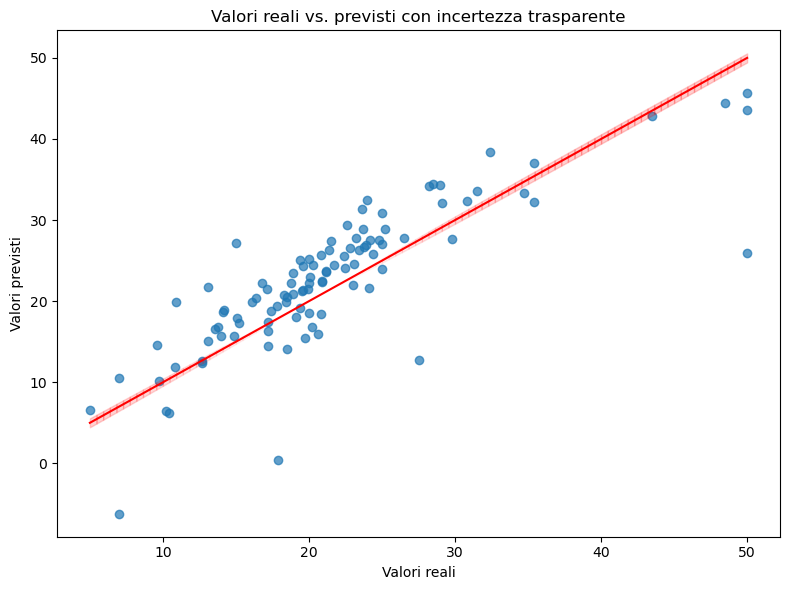

In [40]:
# Versione alternativa con fill_between
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)

# Creiamo una griglia di valori sull'asse x (y_test)
x_grid = np.linspace(y_test.min(), y_test.max(), 100)

# Stimiamo la densità in ogni punto
kde = gaussian_kde(y_test)
densities = kde(x_grid)
densities = densities / densities.max()  # Normalizzazione

# Calcoliamo l'incertezza inversa alla densità
uncertainty = 0.5 * (1 - densities) + 0.1  # Minimo 0.1, massimo 0.6

# Linea principale
plt.plot(x_grid, x_grid, 'r-', linewidth=1.5)

# Area di incertezza con trasparenza variabile
for i in range(len(x_grid)-1):
    plt.fill_between([x_grid[i], x_grid[i+1]], 
                     [x_grid[i] - uncertainty[i], x_grid[i+1] - uncertainty[i+1]],
                     [x_grid[i] + uncertainty[i], x_grid[i+1] + uncertainty[i+1]],
                     color='r', alpha=0.2 * (1 - densities[i]))

plt.xlabel('Valori reali')
plt.ylabel('Valori previsti')
plt.title('Valori reali vs. previsti con incertezza trasparente')
plt.tight_layout()
plt.show()

* **Punti blu****: Ogni punto rappresenta una casa nel set di test, dove la coordinata x è il prezzo reale e la coordinata y è il prezzo previsto dal modello.
* **Linea rossa tratteggiata**: Rappresenta la linea di perfetta previsione (y = x). Se il modello fosse perfetto, tutti i punti si troverebbero esattamente su questa linea.
* **Distribuzione dei punti**:

    * I punti abbastanza vicini alla linea rossa indicano previsioni ragionevolmente accurate
    * Punti sopra la linea rappresentano case per cui il modello ha sovrastimato il prezzo
    * Punti sotto la linea rappresentano case per cui il modello ha sottostimato il prezzo

Il modello sembra avere un $R²$ di **0.6263**, il che significa che **spiega circa il 63% della varianza nei prezzi delle case**. Questo è un risultato discreto per un modello lineare semplice.

Si possono notare alcuni punti che si discostano significativamente dalla linea, indicando casi dove il modello ha fatto previsioni meno accurate. Ad esempio, in basso a sinistra c'è un punto con valore reale intorno a 10 ma valore previsto vicino a -5.

> Il modello **funziona meglio nella fascia media dei prezzi**, mentre sembra avere difficoltà con alcune case di valore più alto o più basso rispetto alla media, il che è comune nei modelli lineari che potrebbero non catturare completamente relazioni non lineari nei dati.

## Part 2: Logistic Regression - Breast Cancer Classification

### Task
- Load the Breast Cancer dataset
- Preprocess the data
- Split into training and testing sets
- Train a Logistic Regression model
- Evaluate model performance

In [16]:
breast_cancer = load_breast_cancer()
X_cancer = pd.DataFrame(breast_cancer.data, columns=breast_cancer.feature_names)
y_cancer = breast_cancer.target

In [17]:
# TODO: Split the data into training and testing sets
X_cancer_train, X_cancer_test, y_cancer_train, y_cancer_test = train_test_split(X_cancer,
                                                                                y_cancer, 
                                                                                test_size=0.2, 
                                                                                random_state=42)

In [18]:
X_cancer_train.head().T

,68,181,63,248,60
mean radius,9.029000,21.090000,9.173000,10.650000,10.170000
mean texture,17.330000,26.570000,13.860000,25.220000,14.880000
mean perimeter,58.790000,142.700000,59.200000,68.010000,64.550000
mean area,250.500000,1311.000000,260.900000,347.000000,311.900000
mean smoothness,0.106600,0.114100,0.077210,0.096570,0.113400
mean compactness,0.141300,0.283200,0.087510,0.072340,0.080610
mean concavity,0.313000,0.248700,0.059880,0.023790,0.010840
mean concave points,0.043750,0.149600,0.021800,0.016150,0.012900
mean symmetry,0.211100,0.239500,0.234100,0.189700,0.274300
mean fractal dimension,0.080460,0.073980,0.069630,0.063290,0.069600


In [19]:
X_cancer_train.dtypes

mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst symmetry      

In [20]:
y_cancer_train

array([1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1,

In [21]:
# controllo i set
len(X_cancer_train), len(y_cancer_train), len(X_cancer_test), len(y_cancer_test)

(455, 455, 114, 114)

In [22]:
# TODO: Scale the features
# Sono tutti valori rumerici quindi uso lo standard Scaler
scaler_cancer = StandardScaler()

X_cancer_train_scaled = scaler_cancer.fit_transform(X_cancer_train)
X_cancer_test_scaled = scaler_cancer.fit_transform(X_cancer_test)

In [23]:
# TODO: Train a Logistic Regression model
# istanzio il modello
cl_model = LogisticRegression()
cl_model.fit(X_cancer_train_scaled, y_cancer_train)

LogisticRegression()

In [24]:
# TODO: Make predictions and calculate performance metrics
y_cancer_pred = cl_model.predict(X_cancer_test_scaled)
accuracy = accuracy_score(y_cancer_test, y_cancer_pred)

#### Guardo le matrici di confusione

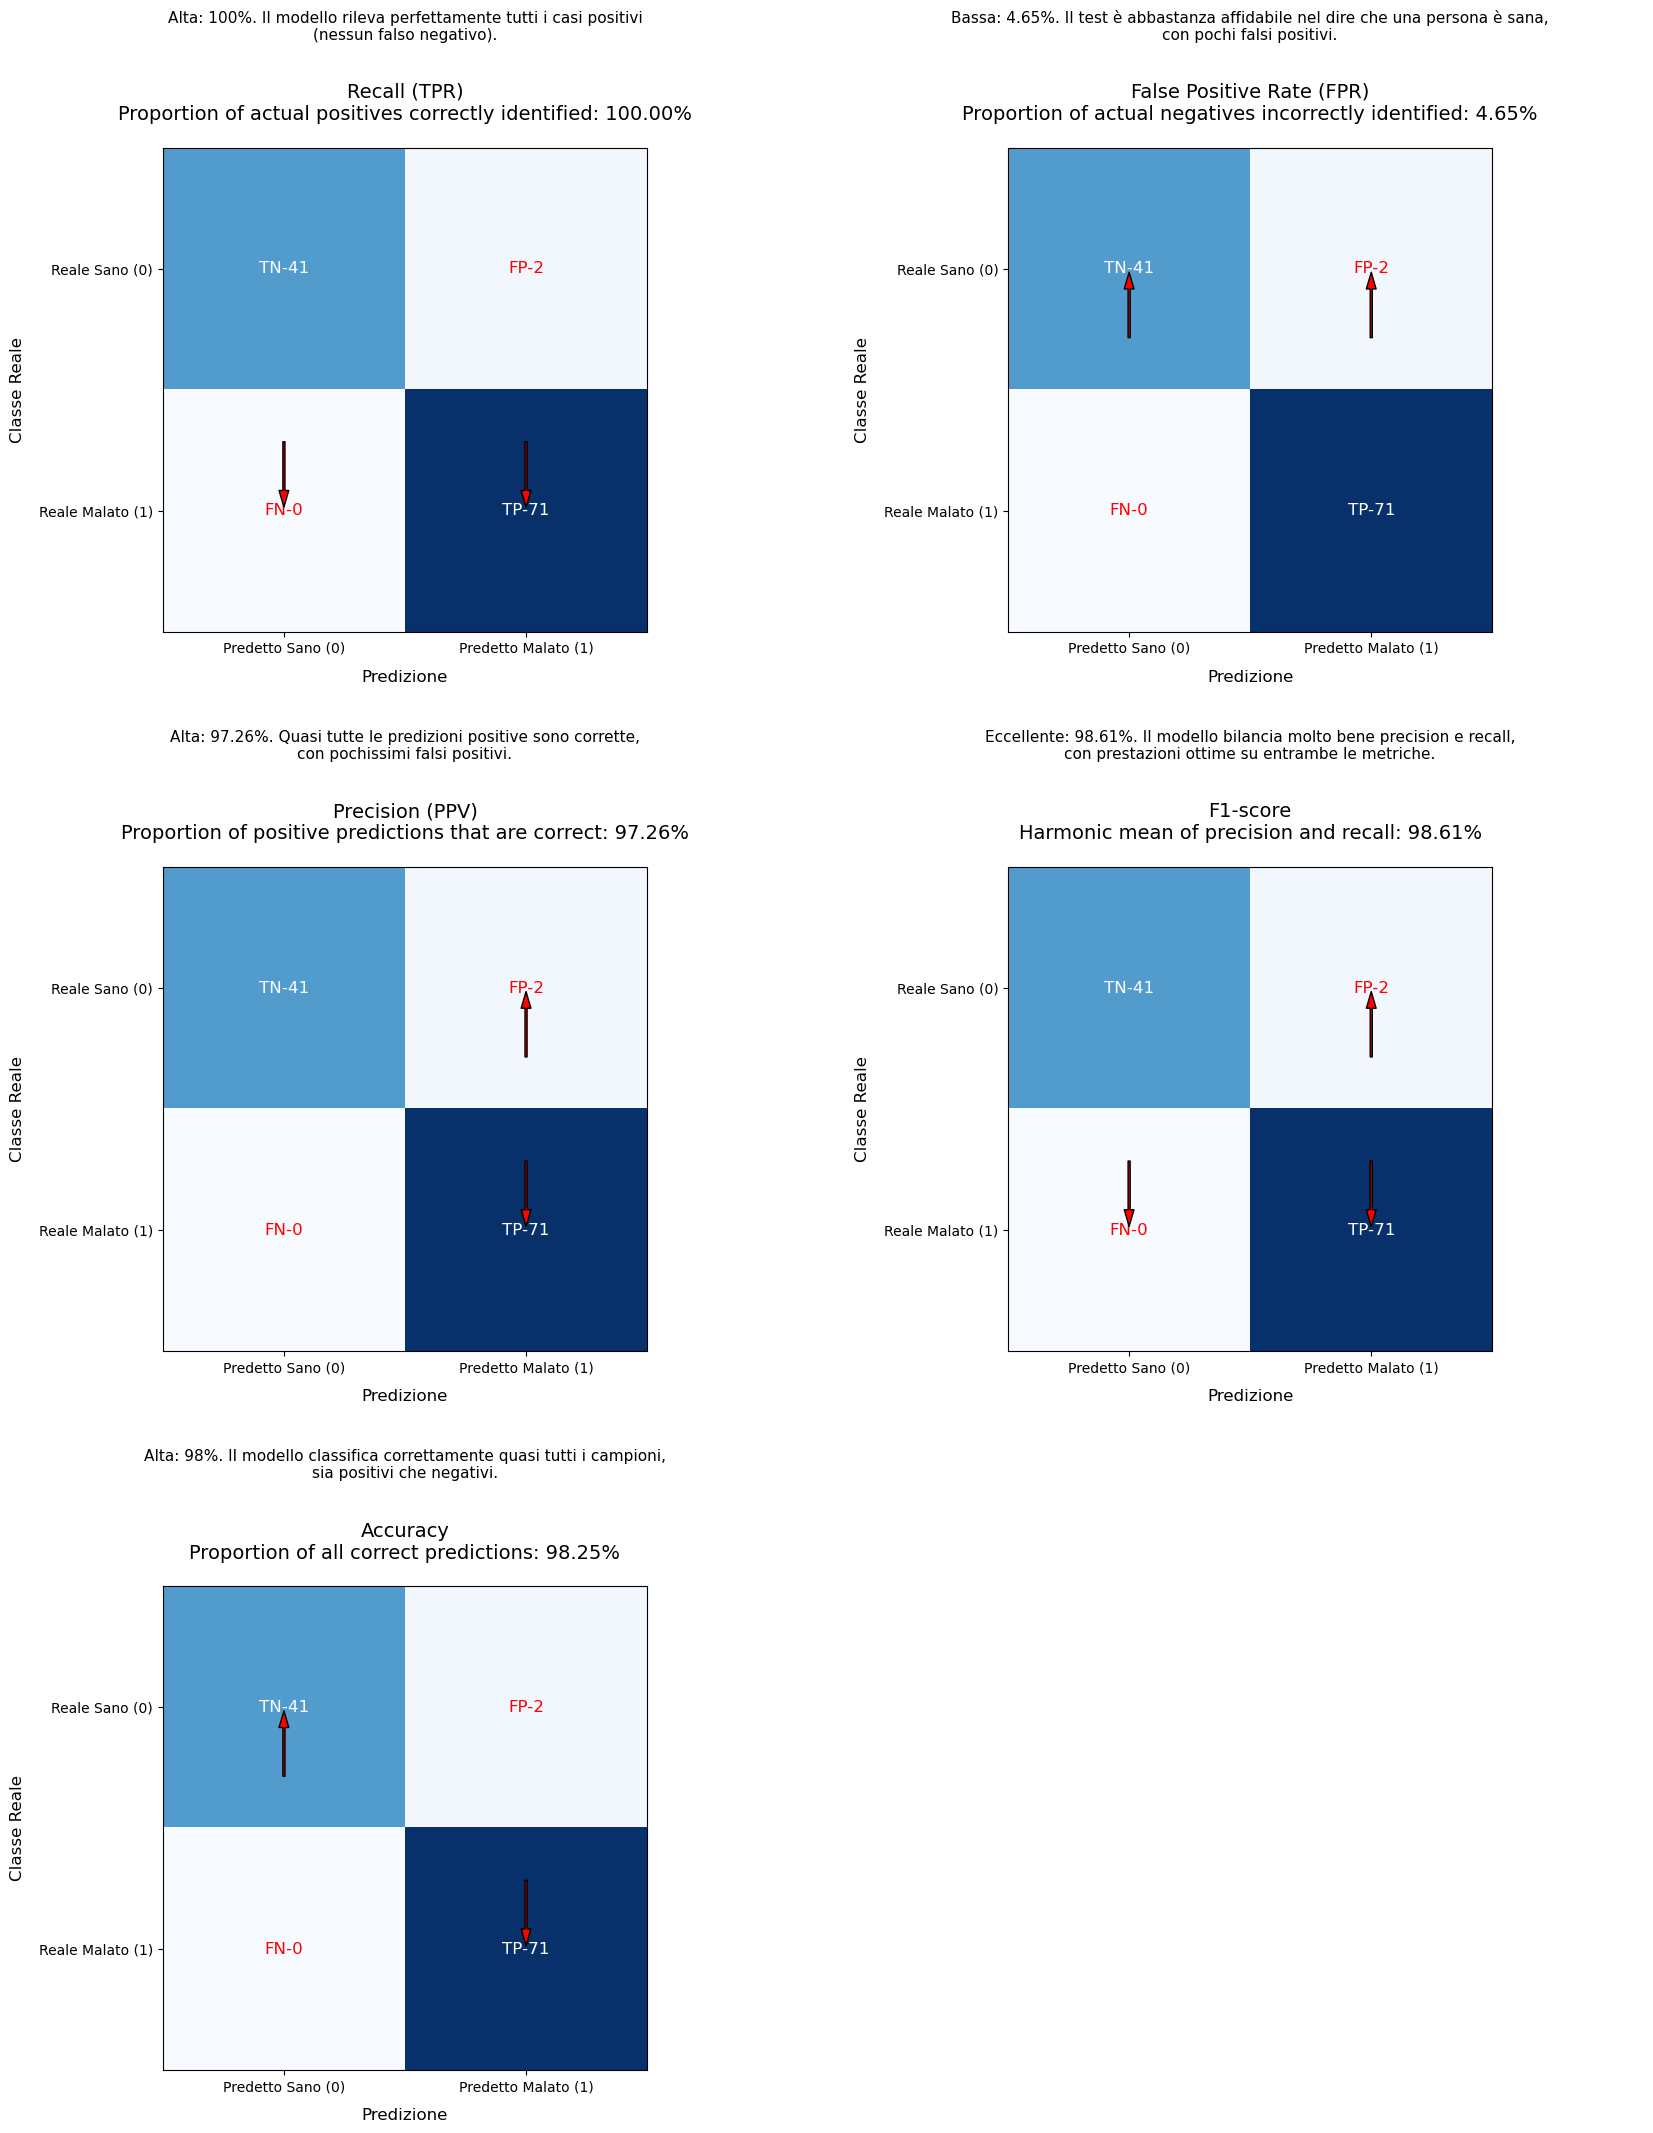

In [37]:
# Importazioni necessarie
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score
import matplotlib.patches as patches

# Ottieni la matrice di confusione
cm = confusion_matrix(y_cancer_test, y_cancer_pred)
tn, fp, fn, tp = cm.ravel()

# Calcola le metriche
recall = recall_score(y_cancer_test, y_cancer_pred)
precision = precision_score(y_cancer_test, y_cancer_pred)
f1 = f1_score(y_cancer_test, y_cancer_pred)
fpr = fp / (fp + tn)  # False Positive Rate
accuracy = (tn + tp) / (tn + fp + fn + tp)

# Crea una figura con 4 sottografici
fig, axes = plt.subplots(3, 2, figsize=(18, 22))

# Funzione per creare la visualizzazione della matrice di confusione
def plot_confusion_metric(ax, cm, title, metric_value, description, cells_to_highlight=None, cmap='Blues'):
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.set_title(f"{title}: {metric_value:.2%}", fontsize=14, pad=20)
    
    # Aggiungi annotazioni
    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if i == j:
                color = "white" if cm[i, j] > thresh else "black"
                ax.text(j, i, f"TN-{cm[0,0]}" if i==0 and j==0 else f"TP-{cm[1,1]}", 
                        ha="center", va="center", fontsize=12, color=color)
            else:
                color = "red"
                ax.text(j, i, f"FN-{cm[1,0]}" if i==1 and j==0 else f"FP-{cm[0,1]}", 
                        ha="center", va="center", fontsize=12, color=color)
    
    # Configura gli assi
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Predetto Sano (0)', 'Predetto Malato (1)'])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Reale Sano (0)', 'Reale Malato (1)'])
    ax.set_xlabel('Predizione', fontsize=12, labelpad=10)
    ax.set_ylabel('Classe Reale', fontsize=12, labelpad=10)
    
    # Aggiungi il commento sul grafico
    ax.text(0.5, 1.25, description, ha='center', va='center', 
            transform=ax.transAxes, fontsize=11)
    
    # Aggiungi frecce per evidenziare le celle usate nel calcolo
    if cells_to_highlight:
        for cell in cells_to_highlight:
            i, j = cell
            # Crea una freccia rossa che punta alla cella
            ax.annotate('', xy=(j, i), xytext=(j, i+0.3 if i==0 else i-0.3),
                        arrowprops=dict(facecolor='red', shrink=0.05, width=1.5, headwidth=7))

# Grafico del Recall (TPR)
plot_confusion_metric(
    axes[0, 0], cm, 
    "Recall (TPR)\nProportion of actual positives correctly identified", 
    recall,
    "Alta: 100%. Il modello rileva perfettamente tutti i casi positivi\n(nessun falso negativo).",
    cells_to_highlight=[(1, 0), (1, 1)]  # FN e TP (usati per calcolare il recall)
)

# Grafico del False Positive Rate (FPR)
plot_confusion_metric(
    axes[0, 1], cm, 
    "False Positive Rate (FPR)\nProportion of actual negatives incorrectly identified", 
    fpr,
    "Bassa: 4.65%. Il test è abbastanza affidabile nel dire che una persona è sana,\ncon pochi falsi positivi.",
    cells_to_highlight=[(0, 0), (0, 1)]  # TN e FP (usati per calcolare FPR)
)

# Grafico della Precision (PPV)
plot_confusion_metric(
    axes[1, 0], cm, 
    "Precision (PPV)\nProportion of positive predictions that are correct", 
    precision,
    "Alta: 97.26%. Quasi tutte le predizioni positive sono corrette,\ncon pochissimi falsi positivi.",
    cells_to_highlight=[(0, 1), (1, 1)]  # FP e TP (usati per calcolare precision)
)

# Grafico dell'F1-score
plot_confusion_metric(
    axes[1, 1], cm, 
    "F1-score\nHarmonic mean of precision and recall", 
    f1,
    "Eccellente: 98.61%. Il modello bilancia molto bene precision e recall,\ncon prestazioni ottime su entrambe le metriche.",
    cells_to_highlight=[(0, 1), (1, 0), (1, 1)]  # FP, FN e TP (usati indirettamente per F1)
)

# Grafico dell'Accuracy
plot_confusion_metric(
    axes[2,0], cm, 
    "Accuracy\nProportion of all correct predictions", 
    accuracy,
    "Alta: 98%. Il modello classifica correttamente quasi tutti i campioni,\nsia positivi che negativi.",
    cells_to_highlight=[(0, 0), (1, 1)]  # Solo TN e TP (predizioni corrette)
)
# Nascondiamo l'ultimo subplot vuoto
axes[2, 1].axis('off')

plt.tight_layout(pad=3.0)
plt.show()

In [25]:
# TODO: Print performance metrics

print(f"Accuracy: {accuracy: .2f}")
print("Classification Report:")
print(classification_report(y_cancer_test,y_cancer_pred))

Accuracy:  0.98
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



Accuracy: 0.98 - Il modello classifica correttamente il 98% di tutti i casi (eccellente)
Per classe (0 - non cancro, 1 - cancro):

* Precision:

    * Classe 0: 1.00 - Il 100% delle predizioni di classe 0 sono corrette
    * Classe 1: 0.97 - Il 97% delle predizioni di classe 1 sono corrette


* Recall:

    * Classe 0: 0.95 - Il modello identifica correttamente il 95% dei veri casi di classe 0
    * Classe 1: 1.00 - Il modello identifica correttamente il 100% dei veri casi di classe 1


* F1-score:

    * Classe 0: 0.98 - Media armonica di precision e recall per classe 0
    * Classe 1: 0.99 - Media armonica di precision e recall per classe 1


* Support:

    * Classe 0: 43 campioni
    * Classe 1: 71 campioni




* Medie:

* macro avg: Media non ponderata delle metriche per entrambe le classi
* weighted avg: Media ponderata in base al numero di campioni per classe



Questi risultati indicano che il modello di regressione logistica è molto performante, con capacità eccellente di identificare sia i casi positivi (cancro) che quelli negativi (non cancro). La precisione e il recall sono molto alti in entrambe le classi, anche se il modello sembra leggermente migliore nell'identificare i casi positivi (recall 1.00) rispetto ai negativi (recall 0.95).

## Part 3: Decision Tree - Titanic Survival Prediction

### Task
- Load the Titanic dataset
- Preprocess the data (handling missing values, encoding categorical variables)
- Split into training and testing sets
- Train a Decision Tree Classifier
- Evaluate model performance

In [5]:
# Load Titanic dataset
titanic = pd.read_csv('https://web.stanford.edu/class/archive/cs/cs109/cs109.1166/stuff/titanic.csv')

In [6]:
titanic.head()

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500


In [7]:
# Data Preprocessing
# TODO: Handle missing values
# Controllo se ci sono valori null
titanic.isna().sum()

Survived                   0
Pclass                     0
Name                       0
Sex                        0
Age                        0
Siblings/Spouses Aboard    0
Parents/Children Aboard    0
Fare                       0
dtype: int64

In [8]:
# Controllo i tipi 
titanic.dtypes

Survived                     int64
Pclass                       int64
Name                        object
Sex                         object
Age                        float64
Siblings/Spouses Aboard      int64
Parents/Children Aboard      int64
Fare                       float64
dtype: object

In [9]:
# Feature selection

features = ['Pclass', 'Sex', 'Age', 'Fare']
X_titanic = titanic[features]
y_titanic = titanic['Survived']

# Definisco le colonne numeriche da scalare
numeric_features = ['Age', 'Fare']
# Definisco le colonne categoriche
categorical_features = ['Pclass', 'Sex']

In [41]:
X_titanic.dtypes

Pclass      int64
Sex        object
Age       float64
Fare      float64
dtype: object

In [10]:
# TODO: Scale the features
numeric_transformer = StandardScaler()

# Creare un nuovo DataFrame con i valori scalati
X_titanic_scaled = X_titanic.copy()
X_titanic_scaled.loc[:, numeric_features] = numeric_transformer.fit_transform(X_titanic[numeric_features])

In [11]:
# TODO: Encode the features


# Crea e applica l'encoder
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded_features = encoder.fit_transform(X_titanic[categorical_features])

# Crea un DataFrame con le feature codificate
feature_names = encoder.get_feature_names_out(categorical_features)
encoded_df = pd.DataFrame(
    encoded_features, 
    columns=feature_names,
    index=X_titanic.index
)

In [42]:
encoded_df.head()

,Pclass_2,Pclass_3,Sex_male
0,0.0,1.0,1.0
1,0.0,0.0,0.0
2,0.0,1.0,0.0
3,0.0,0.0,0.0
4,0.0,1.0,1.0


In [12]:
# Unisci le feature numeriche scalate con quelle categoriche codificate
X_titanic_processed = pd.concat([X_titanic_scaled[numeric_features], encoded_df], axis=1)

In [13]:
X_titanic_processed.head()

,Age,Fare,Pclass_2,Pclass_3,Sex_male
0,-0.529366,-0.503586,0.0,1.0,1.0
1,0.604265,0.783412,0.0,0.0,0.0
2,-0.245958,-0.490020,0.0,1.0,0.0
3,0.391709,0.417948,0.0,0.0,0.0
4,0.391709,-0.487507,0.0,1.0,1.0


In [14]:
y_titanic

0      0
1      1
2      1
3      1
4      0
      ..
882    0
883    1
884    0
885    1
886    0
Name: Survived, Length: 887, dtype: int64

In [15]:
# TODO: Split the data into training and testing sets
X_titanic_train, X_titanic_test, y_titanic_train, y_titanic_test = train_test_split(X_titanic_processed, 
                                                                                    y_titanic,
                                                                                   test_size=0.2,
                                                                                   random_state=42)

In [16]:
len(X_titanic_train), len(X_titanic_test), len(y_titanic_train), len(y_titanic_test)

(709, 178, 709, 178)

In [17]:
# TODO: Train a Decision Tree Classifier
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42) # max_depth a sentimento, facendo varie prove
tree_model.fit(X_titanic_train, y_titanic_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [18]:
# TODO: Make predictions and calculate performance metrics
# Predict and evaluate

y_titanic_pred = tree_model.predict(X_titanic_test)
accuracy_titanic = accuracy_score(y_titanic_test, y_titanic_pred)


In [19]:
# TODO: Print performance metrics
print(f"Accuracy: {accuracy_titanic:.2f}")
print("Classification Report:")
print(classification_report(y_titanic_test, y_titanic_pred, target_names=["Not Survived", "Survived"]))

Accuracy: 0.78
Classification Report:
              precision    recall  f1-score   support

Not Survived       0.78      0.88      0.83       111
    Survived       0.75      0.60      0.67        67

    accuracy                           0.78       178
   macro avg       0.77      0.74      0.75       178
weighted avg       0.77      0.78      0.77       178



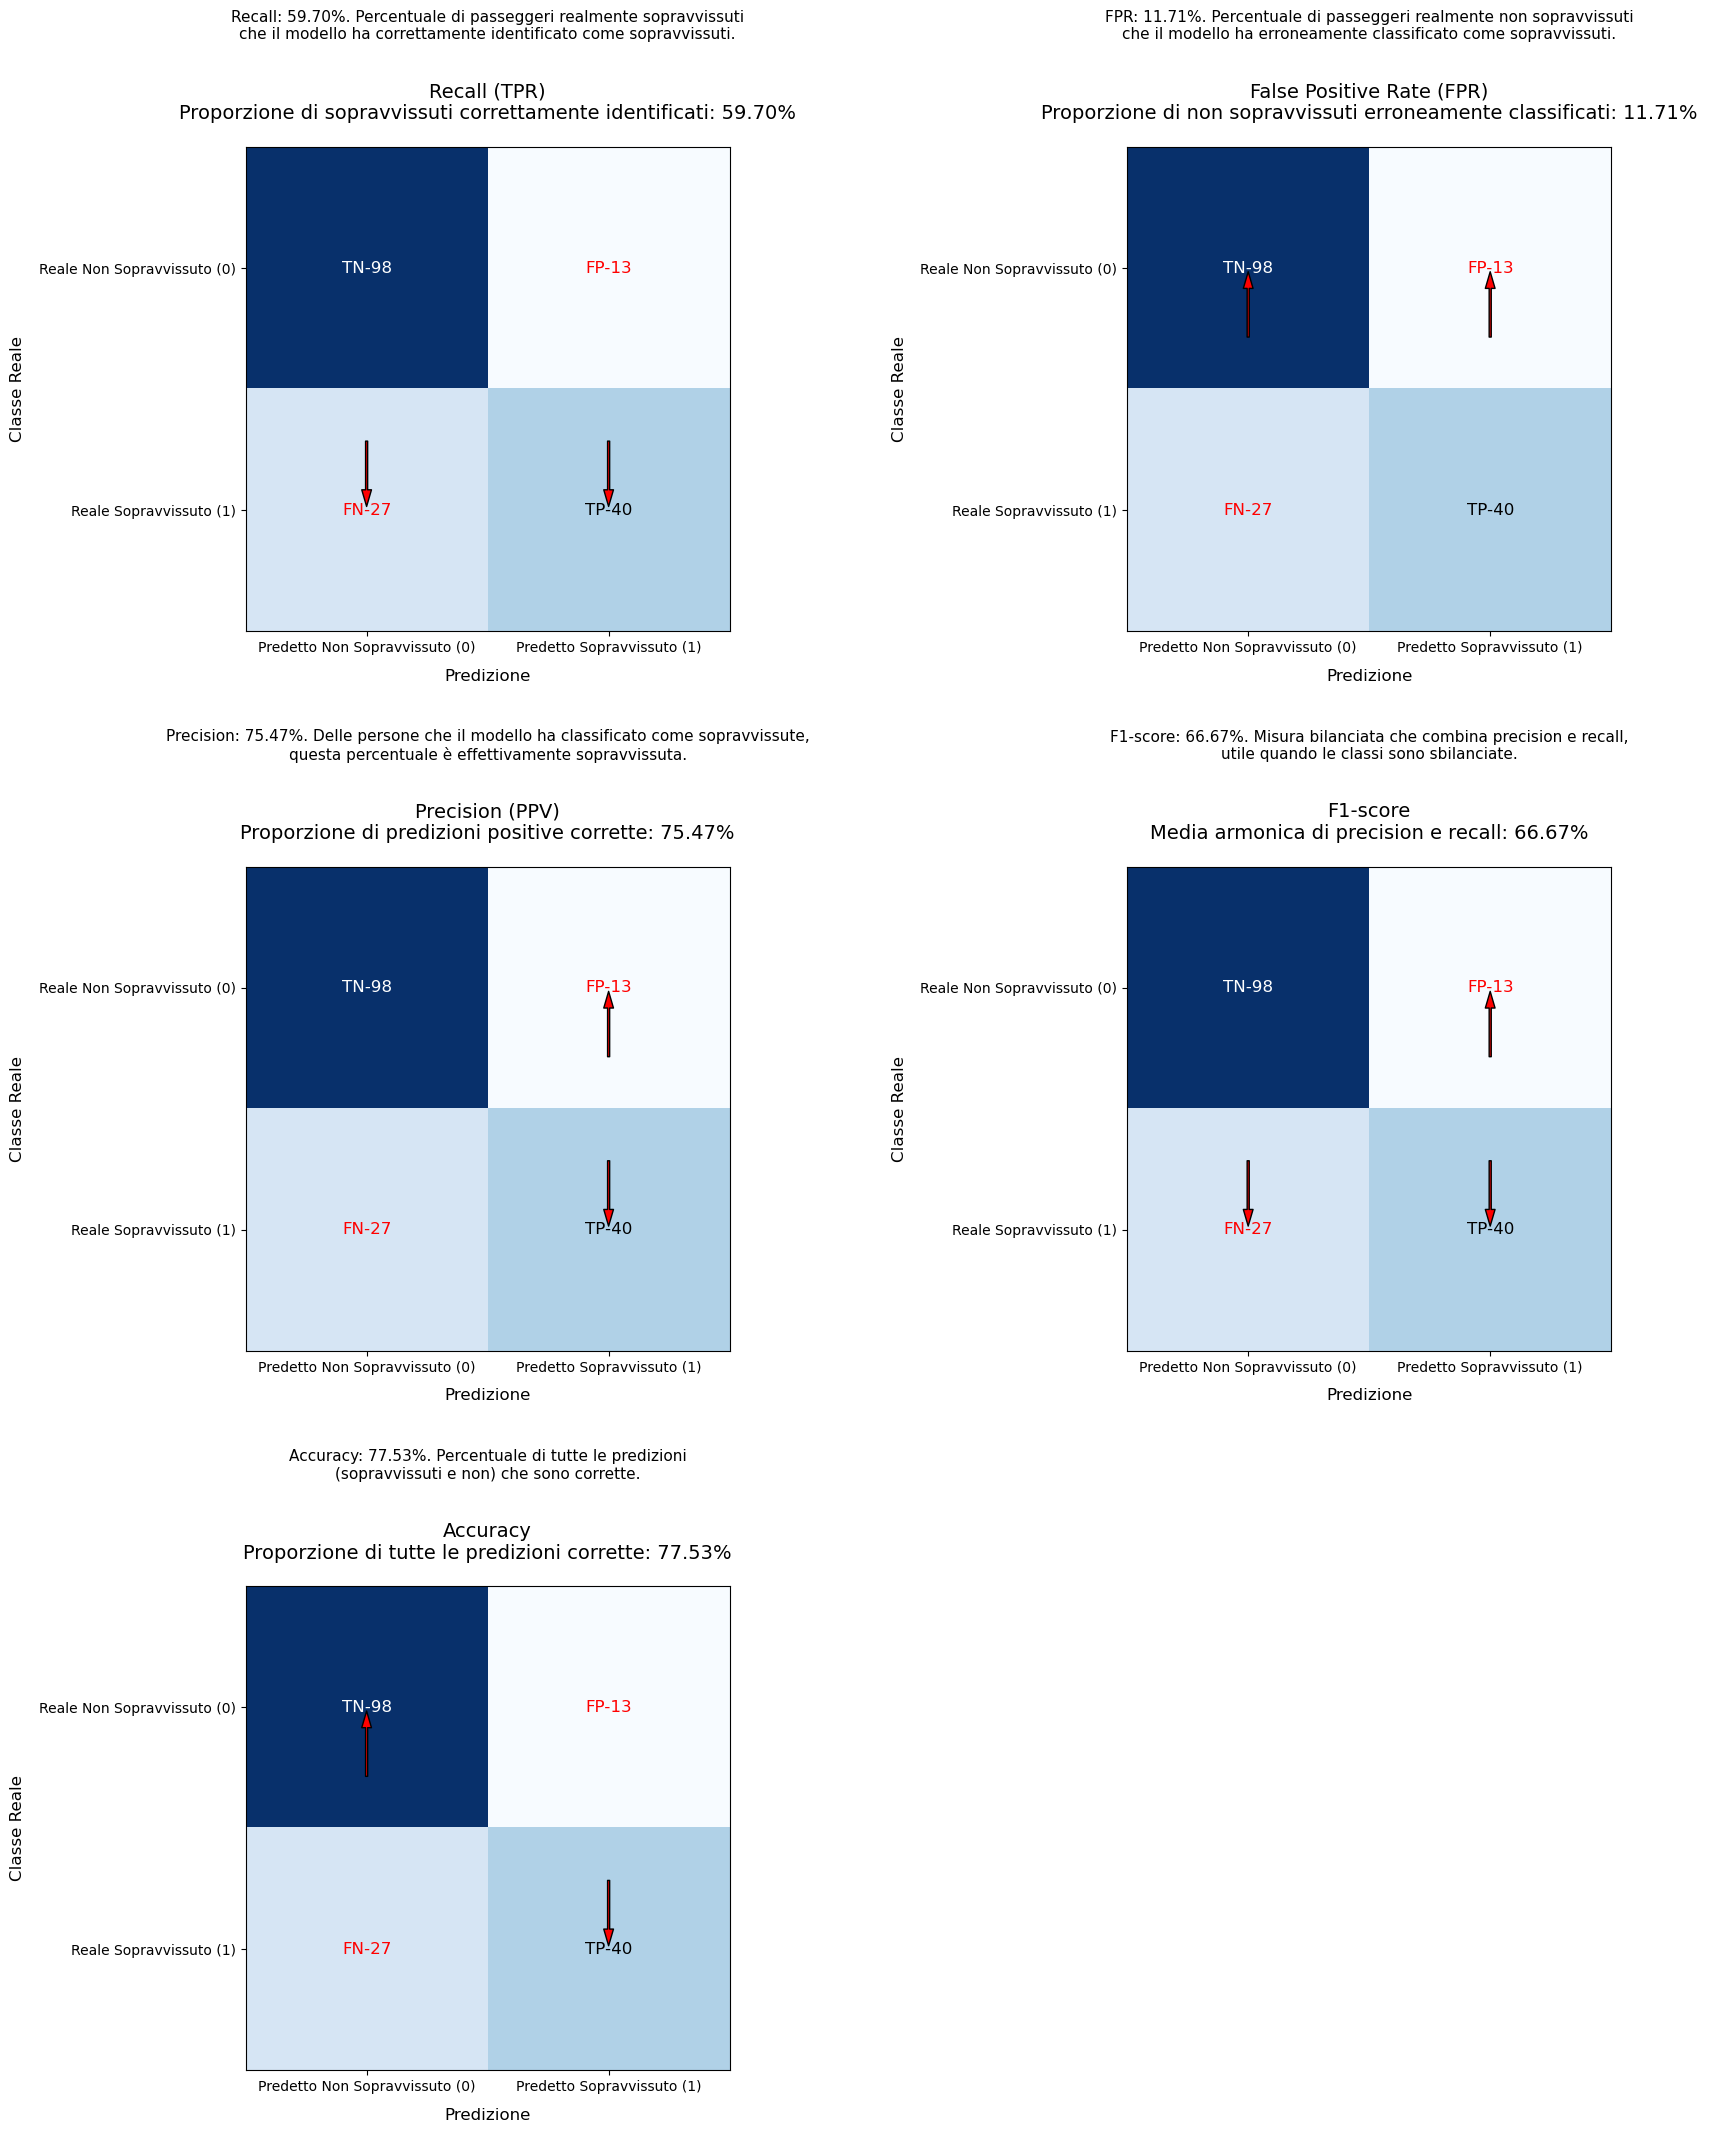

In [20]:
# Importazioni necessarie
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score
import matplotlib.patches as patches

# Ottieni la matrice di confusione per il modello Titanic
cm = confusion_matrix(y_titanic_test, y_titanic_pred)
tn, fp, fn, tp = cm.ravel()

# Calcola le metriche
recall = recall_score(y_titanic_test, y_titanic_pred)
precision = precision_score(y_titanic_test, y_titanic_pred)
f1 = f1_score(y_titanic_test, y_titanic_pred)
fpr = fp / (fp + tn)  # False Positive Rate
accuracy = (tn + tp) / (tn + fp + fn + tp)

# Crea una figura con 4 sottografici
fig, axes = plt.subplots(3, 2, figsize=(18, 22))

# Funzione per creare la visualizzazione della matrice di confusione
def plot_confusion_metric(ax, cm, title, metric_value, description, cells_to_highlight=None, cmap='Blues'):
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.set_title(f"{title}: {metric_value:.2%}", fontsize=14, pad=20)
    
    # Aggiungi annotazioni
    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if i == j:
                color = "white" if cm[i, j] > thresh else "black"
                ax.text(j, i, f"TN-{cm[0,0]}" if i==0 and j==0 else f"TP-{cm[1,1]}", 
                        ha="center", va="center", fontsize=12, color=color)
            else:
                color = "red"
                ax.text(j, i, f"FN-{cm[1,0]}" if i==1 and j==0 else f"FP-{cm[0,1]}", 
                        ha="center", va="center", fontsize=12, color=color)
    
    # Configura gli assi
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Predetto Non Sopravvissuto (0)', 'Predetto Sopravvissuto (1)'])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Reale Non Sopravvissuto (0)', 'Reale Sopravvissuto (1)'])
    ax.set_xlabel('Predizione', fontsize=12, labelpad=10)
    ax.set_ylabel('Classe Reale', fontsize=12, labelpad=10)
    
    # Aggiungi il commento sul grafico
    ax.text(0.5, 1.25, description, ha='center', va='center', 
            transform=ax.transAxes, fontsize=11)
    
    # Aggiungi frecce per evidenziare le celle usate nel calcolo
    if cells_to_highlight:
        for cell in cells_to_highlight:
            i, j = cell
            # Crea una freccia rossa che punta alla cella
            ax.annotate('', xy=(j, i), xytext=(j, i+0.3 if i==0 else i-0.3),
                        arrowprops=dict(facecolor='red', shrink=0.05, width=1.5, headwidth=7))

# Grafico del Recall (TPR)
plot_confusion_metric(
    axes[0, 0], cm, 
    "Recall (TPR)\nProporzione di sopravvissuti correttamente identificati", 
    recall,
    f"Recall: {recall:.2%}. Percentuale di passeggeri realmente sopravvissuti\nche il modello ha correttamente identificato come sopravvissuti.",
    cells_to_highlight=[(1, 0), (1, 1)]  # FN e TP
)

# Grafico del False Positive Rate (FPR)
plot_confusion_metric(
    axes[0, 1], cm, 
    "False Positive Rate (FPR)\nProporzione di non sopravvissuti erroneamente classificati", 
    fpr,
    f"FPR: {fpr:.2%}. Percentuale di passeggeri realmente non sopravvissuti\nche il modello ha erroneamente classificato come sopravvissuti.",
    cells_to_highlight=[(0, 0), (0, 1)]  # TN e FP
)

# Grafico della Precision (PPV)
plot_confusion_metric(
    axes[1, 0], cm, 
    "Precision (PPV)\nProporzione di predizioni positive corrette", 
    precision,
    f"Precision: {precision:.2%}. Delle persone che il modello ha classificato come sopravvissute,\nquesta percentuale è effettivamente sopravvissuta.",
    cells_to_highlight=[(0, 1), (1, 1)]  # FP e TP
)

# Grafico dell'F1-score
plot_confusion_metric(
    axes[1, 1], cm, 
    "F1-score\nMedia armonica di precision e recall", 
    f1,
    f"F1-score: {f1:.2%}. Misura bilanciata che combina precision e recall,\nutile quando le classi sono sbilanciate.",
    cells_to_highlight=[(0, 1), (1, 0), (1, 1)]  # FP, FN e TP
)

# Grafico dell'Accuracy
plot_confusion_metric(
    axes[2, 0], cm, 
    "Accuracy\nProporzione di tutte le predizioni corrette", 
    accuracy,
    f"Accuracy: {accuracy:.2%}. Percentuale di tutte le predizioni\n(sopravvissuti e non) che sono corrette.",
    cells_to_highlight=[(0, 0), (1, 1)]  # TN e TP
)

# Nascondiamo l'ultimo subplot vuoto
axes[2, 1].axis('off')

plt.tight_layout(pad=3.0)
plt.show()

In [71]:
print(X_titanic_processed.columns)

Index(['Age', 'Fare', 'Pclass_2', 'Pclass_3', 'Sex_male'], dtype='object')


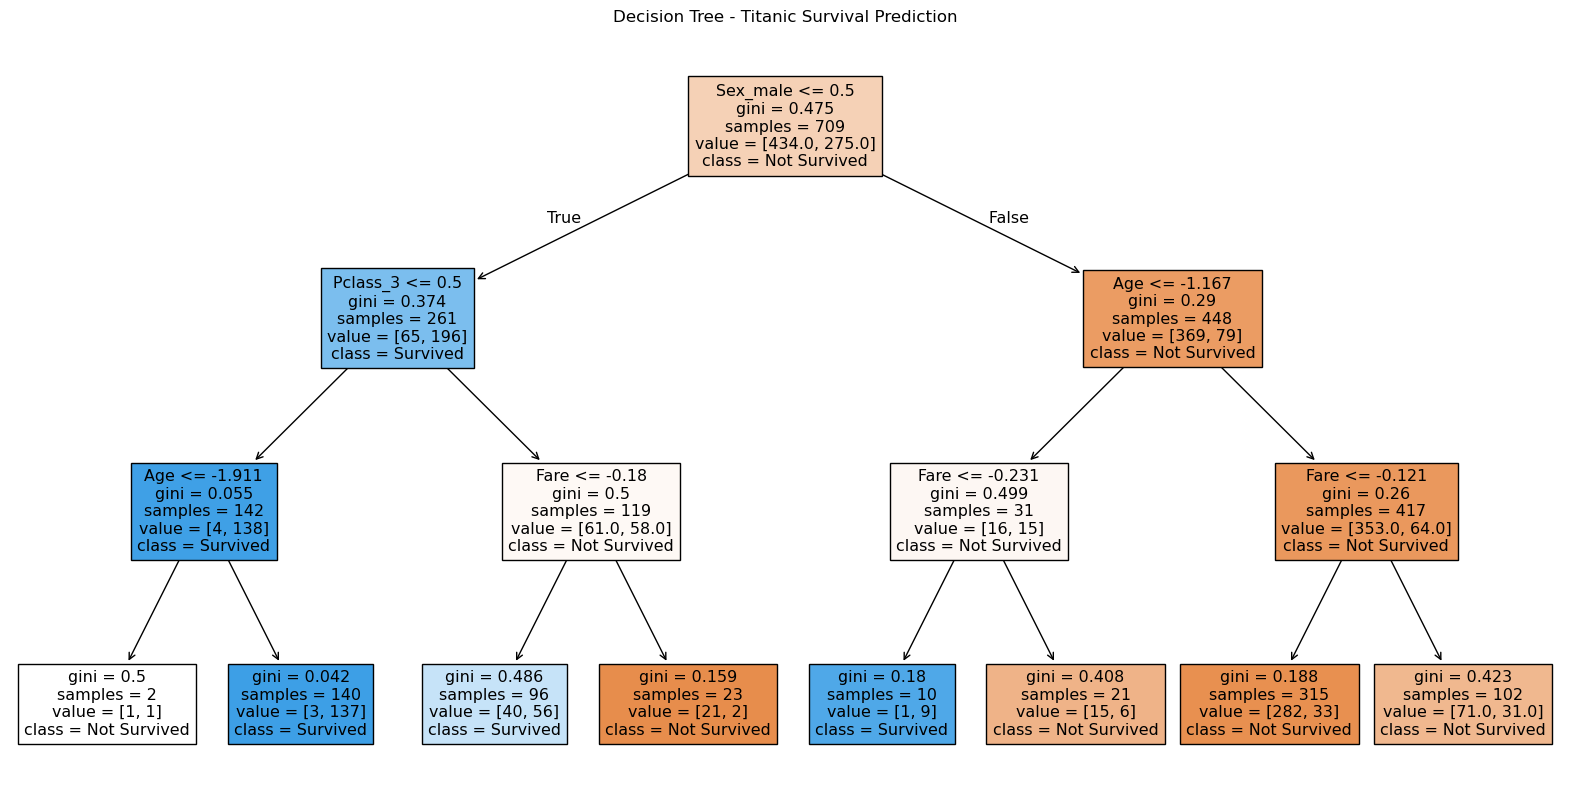

In [72]:
# TODO: Visualize Decisoion Tree
# Visualization of Decision Tree
plt.figure(figsize=(20,10))
plot_tree(tree_model, 
          feature_names=X_titanic_processed.columns,  # Nomi delle feature processate
          class_names=["Not Survived", "Survived"],   # Classi del dataset Titanic
          filled=True)
plt.title("Decision Tree - Titanic Survival Prediction")
plt.show()

1. Regola principale: Il **primo split è basato sul sesso**. Se il passeggero è maschio (`Sex_male <= 0.5` è falso), tende a non sopravvivere, con un indice Gini di 0.475, indicando una buona separazione ma non perfetta.

2. Per i maschi (ramo destro):
* L'età diventa il fattore successivo: i maschi più giovani (Age <= -1.167, che rappresenta età standardizzata) hanno maggiori probabilità di sopravvivenza
* La tariffa del biglietto è un altro fattore importante: tariffe più alte (Fare <= -0.121 è falso) sono associate a maggiori probabilità di sopravvivenza


3. Per le femmine (ramo sinistro):
* La classe è cruciale: donne in prima classe (Pclass_3 <= 0.5 è vero) hanno alta probabilità di sopravvivenza
* Per le donne nella prima classe, l'età è un fattore ulteriore (Age <= -1.911)
* Anche la tariffa (Fare <= -0.18) influisce sulla sopravvivenza delle donne


4. Osservazioni generali:
* Il nodo radice mostra che il campione totale contiene 275 passeggeri
* I valori di Gini più bassi (come 0.042) indicano nodi molto "puri" dove la previsione è molto affidabile
* Le foglie dell'albero mostrano la classe predominante (class = Survived o class = Not Survived)

5. Conclusioni chiave:
* L'essere donna era il principale fattore di sopravvivenza
* Per gli uomini, l'età giovane e le tariffe alte (indicative di uno status sociale elevato) aumentavano le probabilità di sopravvivenza
* Per le donne, l'essere di prima classe era determinante



I valori numerici come `Age <= -1.167` appaiono negativi perché sono stati standardizzati (media 0, deviazione standard 1), quindi **rappresentano valori sotto la media dell'età**.

> Questo albero conferma la famosa politica **"donne e bambini prima"** durante il disastro del Titanic, oltre all'**influenza della classe sociale sulla sopravvivenza**.